# Experiment 5.0.1 — Three-way Analog-Head Control

Analysis-only notebook. Training is performed by a 9-task Slurm array. This notebook aggregates finalized results for three analog-head controls and compares them with historical Exp3.0.5 and Exp5.0 references.

The design separates three possible causes of the Exp3/Exp5 timestep-CE gap: protocol reproduction, hidden-neuron dynamics, and the spiking output path.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / 'notebooks').is_dir():
    ROOT = ROOT.parent
ART = ROOT / 'notebooks' / 'artifacts' / 'experiment_5_0_1_exp3_analog_head_control' / 'analog_head_three_way_control_v3'
runs = pd.read_csv(ART / 'runs.csv')
comparison = pd.read_csv(ART / 'comparison_runs.csv')
manifest = json.loads((ART / 'manifest.json').read_text(encoding='utf-8'))
display(manifest)
display(runs)

{'comparison_sources': ['Exp3.0.5 historical analog-head reference',
  'Exp5.0 timestep_ce binary spiking-output reference',
  'Exp5.0 timestep_ce multi_ho spiking-output reference'],
 'conditions': ['exp3_exact_analog',
  'exp3_synaptic_exp5stream_analog',
  'exp5_macro_exp5stream_analog'],
 'expected_runs': 9,
 'experiment_id': 'experiment_5_0_1_exp3_analog_head_control',
 'files': {'comparison_runs': 'comparison_runs.csv', 'runs': 'runs.csv'},
 'notebook_role': 'compute mean/SD, paired deltas, and plots from finalized run tables',
 'objective': 'timestep_ce',
 'primary_probes': ['full_count', 'fixed250_ordered', 'relative10_ordered'],
 'protocol_version': 'analog_head_three_way_control_v3',
 'seeds': [11, 23, 101]}

,source,condition,seed,native_test_ba,native_val_ba,best_epoch,full_count_test_ba,full_count_val_ba,fixed250_ordered_test_ba,fixed250_ordered_val_ba,...,fixed250_pca128_test_ba,fixed250_pca128_val_ba,relative10_ordered_test_ba,relative10_ordered_val_ba,relative10_shuffled_test_ba,relative10_shuffled_val_ba,relative10_pca128_test_ba,relative10_pca128_val_ba,duration_only_test_ba,duration_only_val_ba
0,exp5_0_1_control,exp3_exact_analog,11,0.474741,0.475439,94,0.513955,0.542334,0.642111,0.588041,...,0.624427,0.531097,0.715334,0.647306,0.538854,0.519493,0.685646,0.598413,0.113095,0.131944
1,exp5_0_1_control,exp3_exact_analog,23,0.487338,0.477652,96,0.537840,0.532690,0.599084,0.599657,...,0.586871,0.511117,0.644762,0.619402,0.555240,0.442695,0.684912,0.595587,0.113095,0.131944
2,exp5_0_1_control,exp3_exact_analog,101,0.515784,0.487975,98,0.625915,0.539400,0.636640,0.526593,...,0.561695,0.512410,0.685904,0.637422,0.582946,0.505994,0.661869,0.602369,0.113095,0.131944
3,exp5_0_1_control,exp3_synaptic_exp5stream_analog,11,0.505527,0.444414,97,0.580086,0.497727,0.596604,0.560895,...,0.585331,0.439063,0.688844,0.588173,0.501952,0.487885,0.624472,0.532961,0.113095,0.131944
4,exp5_0_1_control,exp3_synaptic_exp5stream_analog,23,0.425413,0.426491,70,0.521577,0.502417,0.599625,0.564947,...,0.570262,0.518657,0.638652,0.629714,0.510464,0.423551,0.617979,0.600643,0.113095,0.131944
5,exp5_0_1_control,exp3_synaptic_exp5stream_analog,101,0.502416,0.450896,99,0.598830,0.550637,0.612746,0.561580,...,0.531227,0.520869,0.687953,0.639394,0.568534,0.514658,0.696086,0.596639,0.113095,0.131944
6,exp5_0_1_control,exp5_macro_exp5stream_analog,11,0.504264,0.445509,99,0.550250,0.507065,0.621081,0.505273,...,0.559787,0.480730,0.687347,0.563312,0.515304,0.440458,0.655835,0.578788,0.113095,0.131944
7,exp5_0_1_control,exp5_macro_exp5stream_analog,23,0.492508,0.427122,81,0.532217,0.479473,0.597768,0.521435,...,0.558457,0.536947,0.629611,0.609013,0.464150,0.425770,0.637013,0.559608,0.113095,0.131944
8,exp5_0_1_control,exp5_macro_exp5stream_analog,101,0.489803,0.483634,83,0.504119,0.539268,0.609959,0.531818,...,0.624659,0.548286,0.659050,0.654251,0.568527,0.509602,0.665566,0.605399,0.113095,0.131944


## New-control aggregate

Each condition uses seeds `(11, 23, 101)`. Mean, SD, and count are computed here from finalized per-seed rows.

In [2]:
primary_columns = [
    'native_test_ba',
    'full_count_test_ba',
    'fixed250_ordered_test_ba',
    'relative10_ordered_test_ba',
]
new_summary = runs.groupby('condition')[primary_columns].agg(['mean', 'std', 'count'])
display(new_summary)

native_test_ba                  \
                                          mean       std count   
condition                                                        
exp3_exact_analog                     0.492621  0.021025     3   
exp3_synaptic_exp5stream_analog       0.477785  0.045382     3   
exp5_macro_exp5stream_analog          0.495525  0.007688     3   

                                full_count_test_ba                  \
                                              mean       std count   
condition                                                            
exp3_exact_analog                         0.559237  0.058967     3   
exp3_synaptic_exp5stream_analog           0.566831  0.040296     3   
exp5_macro_exp5stream_analog              0.528862  0.023248     3   

                                fixed250_ordered_test_ba                  \
                                                    mean       std count   
condition                                                                  
exp3_exact_analog                               0.625945  0.023422     3   
exp3_synaptic_exp5stream_analog                 0.602992  0.008581     3   
exp5_macro_exp5stream_analog                    0.609602  0.011661     3   

                                relative10_ordered_test_ba                  
                                                      mean       std count  
condition                                                                   
exp3_exact_analog                                 0.682000  0.035447     3  
exp3_synaptic_exp5stream_analog                   0.671816  0.028725     3  
exp5_macro_exp5stream_analog                      0.658669  0.028870     3

## Unified comparison table

`native_or_output_ba` is native analog-head segment BA for Exp3/new controls and Output WholeCount BA for the historical Exp5 spiking-output references. The L2 frozen-probe columns are the directly comparable representation diagnostics.

In [3]:
metric_columns = [
    'native_or_output_ba',
    'full_count_ba',
    'fixed250_ordered_ba',
    'relative10_ordered_ba',
]
comparison_summary = (
    comparison.groupby(['source', 'variant'])[metric_columns]
    .agg(['mean', 'std', 'count'])
)
display(comparison_summary)

native_or_output_ba  \
                                                                               mean   
source                          variant                                               
exp3_0_5_reference              historical_exp3_analog                     0.492621   
exp5_0_1_control                exp3_exact_analog                          0.492621   
                                exp3_synaptic_exp5stream_analog            0.477785   
                                exp5_macro_exp5stream_analog               0.495525   
exp5_0_spiking_output_reference binary                                     0.328668   
                                multi_ho                                   0.482136   

                                                                           \
                                                                      std   
source                          variant                                     
exp3_0_5_reference              historical_exp3_analog           0.021025   
exp5_0_1_control                exp3_exact_analog                0.021025   
                                exp3_synaptic_exp5stream_analog  0.045382   
                                exp5_macro_exp5stream_analog     0.007688   
exp5_0_spiking_output_reference binary                           0.037193   
                                multi_ho                         0.014762   

                                                                       \
                                                                count   
source                          variant                                 
exp3_0_5_reference              historical_exp3_analog              3   
exp5_0_1_control                exp3_exact_analog                   3   
                                exp3_synaptic_exp5stream_analog     3   
                                exp5_macro_exp5stream_analog        3   
exp5_0_spiking_output_reference binary                              5   
                                multi_ho                            5   

                                                                full_count_ba  \
                                                                         mean   
source                          variant                                         
exp3_0_5_reference              historical_exp3_analog               0.559237   
exp5_0_1_control                exp3_exact_analog                    0.559237   
                                exp3_synaptic_exp5stream_analog      0.566831   
                                exp5_macro_exp5stream_analog         0.528862   
exp5_0_spiking_output_reference binary                               0.405939   
                                multi_ho                             0.577823   

                                                                           \
                                                                      std   
source                          variant                                     
exp3_0_5_reference              historical_exp3_analog           0.058967   
exp5_0_1_control                exp3_exact_analog                0.058967   
                                exp3_synaptic_exp5stream_analog  0.040296   
                                exp5_macro_exp5stream_analog     0.023248   
exp5_0_spiking_output_reference binary                           0.036892   
                                multi_ho                         0.035291   

                                                                       \
                                                                count   
source                          variant                                 
exp3_0_5_reference              historical_exp3_analog              3   
exp5_0_1_control                exp3_exact_analog                   3   
                                exp3_synaptic_exp5stream_analog     3   
                                exp5_macro_exp5stream_analog      

## Gate 1 — exact Exp3 reproduction

Compare `exp3_exact_analog` against historical Exp3.0.5 on the exact three seeds. Near-zero paired deltas are the prerequisite for any mechanistic interpretation.

In [4]:
exp3_exact = comparison[(comparison['source'] == 'exp5_0_1_control') & (comparison['variant'] == 'exp3_exact_analog')].set_index('seed')
historical_exp3 = comparison[comparison['source'] == 'exp3_0_5_reference'].set_index('seed')
common_repro = sorted(set(exp3_exact.index) & set(historical_exp3.index))
paired_reproduction = pd.DataFrame(index=common_repro)
for metric in metric_columns:
    paired_reproduction[metric] = exp3_exact.loc[common_repro, metric] - historical_exp3.loc[common_repro, metric]
display(paired_reproduction)
display(pd.DataFrame({'mean_delta': paired_reproduction.mean(), 'sd_delta': paired_reproduction.std()}))

,native_or_output_ba,full_count_ba,fixed250_ordered_ba,relative10_ordered_ba
11,0.0,0.0,0.0,0.0
23,0.0,0.0,0.0,0.0
101,0.0,0.0,0.0,0.0


,mean_delta,sd_delta
native_or_output_ba,0.0,0.0
full_count_ba,0.0,0.0
fixed250_ordered_ba,0.0,0.0
relative10_ordered_ba,0.0,0.0


## Gate 2 — hidden-dynamics effect under the same Exp5 stream

`exp3_synaptic_exp5stream_analog` and `exp5_macro_exp5stream_analog` use the same Exp5 initialization stream, the same train/val/test loader streams, the same analog head, the same objective, and the same checkpoint rule. Their paired difference therefore isolates the hidden-neuron implementation as tightly as this experiment allows.

In [5]:
syn_exp5stream = comparison[(comparison['source'] == 'exp5_0_1_control') & (comparison['variant'] == 'exp3_synaptic_exp5stream_analog')].set_index('seed')
macro_exp5stream = comparison[(comparison['source'] == 'exp5_0_1_control') & (comparison['variant'] == 'exp5_macro_exp5stream_analog')].set_index('seed')
common_hidden = sorted(set(syn_exp5stream.index) & set(macro_exp5stream.index))
paired_hidden = pd.DataFrame(index=common_hidden)
for metric in metric_columns:
    paired_hidden[metric] = macro_exp5stream.loc[common_hidden, metric] - syn_exp5stream.loc[common_hidden, metric]
display(paired_hidden)
display(pd.DataFrame({'mean_delta_macro_minus_synaptic': paired_hidden.mean(), 'sd_delta': paired_hidden.std()}))

,native_or_output_ba,full_count_ba,fixed250_ordered_ba,relative10_ordered_ba
11,-0.001263,-0.029836,0.024477,-0.001497
23,0.067095,0.010640,-0.001858,-0.009041
101,-0.012612,-0.094711,-0.002787,-0.028903


,mean_delta_macro_minus_synaptic,sd_delta
native_or_output_ba,0.017740,0.043118
full_count_ba,-0.037969,0.053144
fixed250_ordered_ba,0.006611,0.015480
relative10_ordered_ba,-0.013147,0.014157


## Gate 3 — analog head versus Exp5 spiking-output path

Compare `exp5_macro_exp5stream_analog` with historical Exp5 `timestep_ce + binary`. The hidden forward dynamics and Exp5 random/data stream are matched by construction, but only common seeds `11` and `23` exist in both experiments and are treated as paired. `multi_ho` is included as an output-capacity reference, not as an exact architecture pair.

In [6]:
paired_exp5_tables = {}
for variant in ('binary', 'multi_ho'):
    ref = comparison[(comparison['source'] == 'exp5_0_spiking_output_reference') & (comparison['variant'] == variant)].set_index('seed')
    common_exp5 = sorted(set(macro_exp5stream.index) & set(ref.index))
    delta = pd.DataFrame(index=common_exp5)
    for metric in metric_columns:
        delta[metric] = macro_exp5stream.loc[common_exp5, metric] - ref.loc[common_exp5, metric]
    paired_exp5_tables[variant] = delta
    print(f'Exp5-Macro analog - Exp5 {variant}, paired seeds={common_exp5}')
    display(delta)
    display(pd.DataFrame({'mean_delta': delta.mean(), 'sd_delta': delta.std()}))

Exp5-Macro analog - Exp5 binary, paired seeds=[11, 23]


,native_or_output_ba,full_count_ba,fixed250_ordered_ba,relative10_ordered_ba
11,0.190062,0.112113,0.186269,0.152914
23,0.109916,0.123790,0.227341,0.140439


,mean_delta,sd_delta
native_or_output_ba,0.149989,0.056671
full_count_ba,0.117951,0.008257
fixed250_ordered_ba,0.206805,0.029042
relative10_ordered_ba,0.146676,0.008821


Exp5-Macro analog - Exp5 multi_ho, paired seeds=[11, 23]


,native_or_output_ba,full_count_ba,fixed250_ordered_ba,relative10_ordered_ba
11,0.017165,-0.000708,0.081852,0.017249
23,-0.008223,-0.008471,0.054140,-0.023126


,mean_delta,sd_delta
native_or_output_ba,0.004471,0.017952
full_count_ba,-0.004589,0.005489
fixed250_ordered_ba,0.067996,0.019596
relative10_ordered_ba,-0.002939,0.028549


## Representation comparison plot

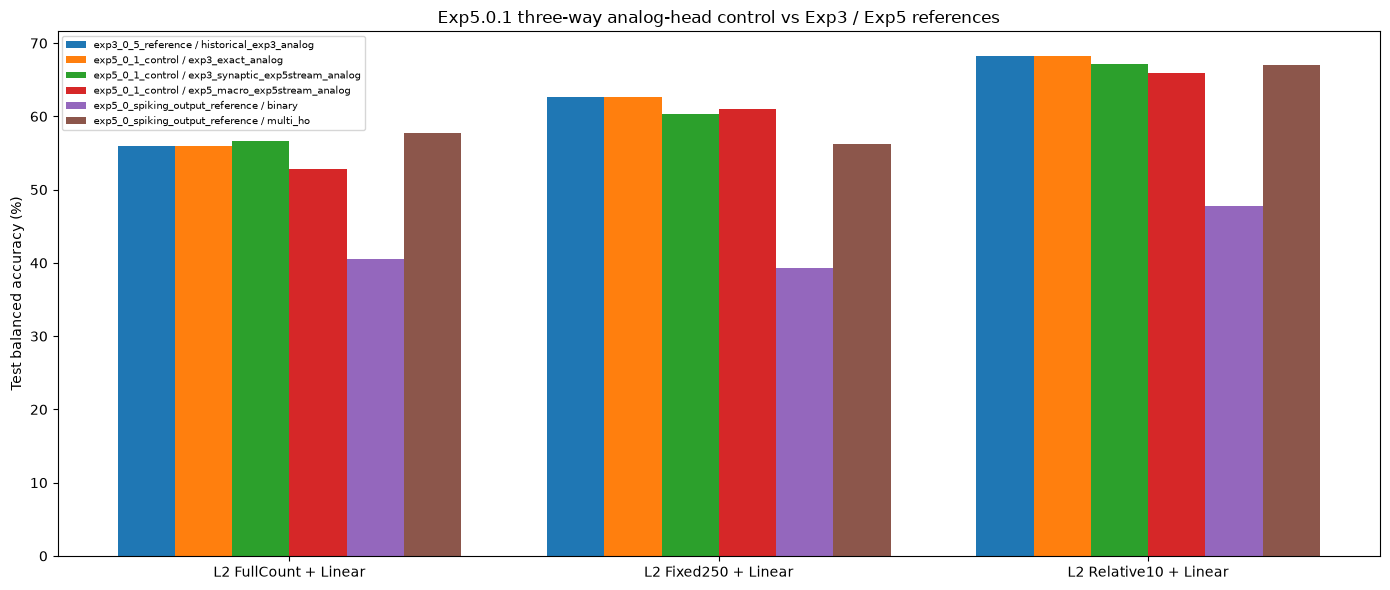

In [7]:
plot_metrics = ['full_count_ba', 'fixed250_ordered_ba', 'relative10_ordered_ba']
labels = {
    'full_count_ba': 'L2 FullCount + Linear',
    'fixed250_ordered_ba': 'L2 Fixed250 + Linear',
    'relative10_ordered_ba': 'L2 Relative10 + Linear',
}
plot_frame = comparison.groupby(['source', 'variant'])[plot_metrics].mean().reset_index()
plot_frame['model'] = plot_frame['source'] + ' / ' + plot_frame['variant']
x = np.arange(len(plot_metrics))
width = 0.8 / len(plot_frame)
fig, ax = plt.subplots(figsize=(14, 6))
for i, row in plot_frame.iterrows():
    values = [100 * row[m] for m in plot_metrics]
    ax.bar(x + (i - (len(plot_frame)-1)/2) * width, values, width=width, label=row['model'])
ax.set_xticks(x, [labels[m] for m in plot_metrics])
ax.set_ylabel('Test balanced accuracy (%)')
ax.set_title('Exp5.0.1 three-way analog-head control vs Exp3 / Exp5 references')
ax.legend(fontsize=7)
fig.tight_layout()
plt.show()

## Interpretation logic

1. If `exp3_exact_analog` does not reproduce historical Exp3, stop and diagnose protocol drift.
2. If reproduction succeeds, use B vs C to measure the hidden implementation effect under the same Exp5 stream.
3. If B and C are close but C is much stronger than existing Exp5 binary, the spiking output path / its optimization and checkpoint regime is the main cause of the timestep-CE degradation.
4. If C is already much weaker than B, hidden dynamics/surrogate implementation contributes materially and the output LIF cannot be blamed alone.
5. Use Multi-HO only to judge whether higher instantaneous output capacity partially compensates for the spiking-output bottleneck.